**Table of contents**<a id='toc0_'></a>    

- [OpenCV Drawing Study Guide](#toc1_)    

  - [Setup - loading image and canvas](#toc1_1_)    

  - [`16.Line segment drawing.pdf`](#toc1_2_)    

  - [`17.Rectangular circle drawing.pdf`](#toc1_3_)    

  - [`18.Text and picture drawing.pdf`](#toc1_4_)    



<!-- vscode-jupyter-toc-config

	numbering=false

	anchor=true

	flat=false

	minLevel=1

	maxLevel=6

	/vscode-jupyter-toc-config -->

<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->


# <a id='toc1_'></a>[OpenCV Drawing Study Guide](#toc0_)



A practical walkthrough of line drawing, shape drawing, and text annotation using the PDFs in this folder.


## <a id='toc1_1_'></a>[Setup - loading image and canvas](#toc0_)



Bring in OpenCV / NumPy / matplotlib, locate a demo image, and prepare a reusable blank canvas for the drawing examples.


In [6]:
import cv2

import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path





def find_image(name: str) -> Path:

    for root in (Path("."), Path(".."), Path("../.."), Path("../../..")):

        path = root / name

        if path.exists():

            return path.resolve()

    raise FileNotFoundError(f"Could not find {name}")





def blank_canvas(width: int = 600, height: int = 600, color=(0, 0, 0)) -> np.ndarray:

    canvas = np.zeros((height, width, 3), dtype=np.uint8)

    canvas[:] = color

    return canvas





img_path = find_image("render1.jpg")

img = cv2.imread(str(img_path), cv2.IMREAD_COLOR)

if img is None:

    raise RuntimeError(f"Failed to read {img_path}")



h, w = img.shape[:2]

print(f"loaded: {img_path.name}   shape={img.shape}   dtype={img.dtype}   {w}x{h}")

print("drawing canvas helper ready: blank_canvas(width, height, color)")


loaded: render1.jpg   shape=(4032, 2268, 3)   dtype=uint8   2268x4032
drawing canvas helper ready: blank_canvas(width, height, color)


## <a id='toc1_2_'></a>[`16.Line segment drawing.pdf`](#toc0_)



What it covers:

- Drawing straight line segments on a blank canvas or existing image.

- Using `pt1` and `pt2` pixel coordinates as the start and end points.

- Controlling color, thickness, and line style, including anti-aliased lines.

- Combining several lines to build larger shapes.


### Drawing straight line segments



`cv2.line` draws one segment at a time onto a destination image. That destination can be a fresh canvas created with NumPy or a copy of an already-loaded photograph.



### Using `pt1` and `pt2` as pixel coordinates



The first point marks where the segment starts and the second point marks where it ends. Both are written as `(x, y)` pixel locations, so moving the numbers changes the line's placement and direction.



### Controlling color, thickness, and line style



You can change the BGR color tuple, increase thickness for bold strokes, or switch to `cv2.LINE_AA` when you want smoother anti-aliased edges.



### Combining several lines into larger shapes



Repeated `cv2.line` calls can outline triangles, arrows, and custom wireframe shapes. This is often the simplest way to build a drawing from primitive geometry.



Core APIs:

- `cv2.line(dst, pt1, pt2, color, thickness, lineType)`

- `cv2.LINE_4`, `cv2.LINE_8`, `cv2.LINE_AA`


line examples:
  basic     -> cv2.line(dst, (70, 90),  (520, 210), (0, 0, 255), 2)
  thick     -> cv2.line(dst, (80, 140), (520, 140), (0, 255, 255), 10)
  aa        -> cv2.line(dst, (70, 90),  (520, 220), (0, 255, 0), 12, cv2.LINE_AA)
  triangle  -> three line calls chained into one closed shape


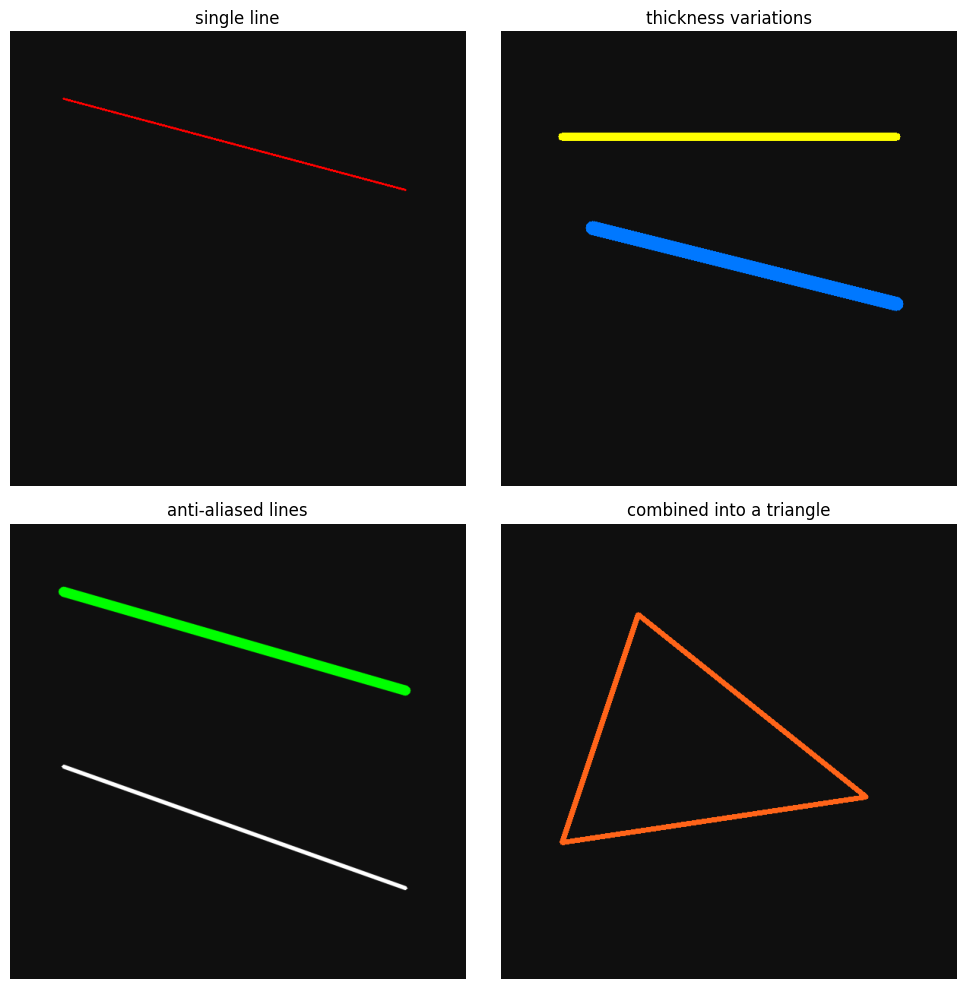

In [7]:
# 16.Line segment drawing.pdf -----------------------------------------------

canvas = blank_canvas(600, 600, color=(15, 15, 15))



line_basic = canvas.copy()

cv2.line(line_basic, (70, 90), (520, 210), (0, 0, 255), 2)



line_thick = canvas.copy()

cv2.line(line_thick, (80, 140), (520, 140), (0, 255, 255), 10)

cv2.line(line_thick, (120, 260), (520, 360), (255, 120, 0), 18)



line_aa = canvas.copy()

cv2.line(line_aa, (70, 90), (520, 220), (0, 255, 0), 12, cv2.LINE_AA)

cv2.line(line_aa, (70, 320), (520, 480), (255, 255, 255), 4, cv2.LINE_AA)



line_shape = canvas.copy()

triangle = [(180, 120), (80, 420), (480, 360)]

cv2.line(line_shape, triangle[0], triangle[1], (25, 100, 255), 6)

cv2.line(line_shape, triangle[1], triangle[2], (25, 100, 255), 6)

cv2.line(line_shape, triangle[2], triangle[0], (25, 100, 255), 6)



print("line examples:")

print("  basic     -> cv2.line(dst, (70, 90),  (520, 210), (0, 0, 255), 2)")

print("  thick     -> cv2.line(dst, (80, 140), (520, 140), (0, 255, 255), 10)")

print("  aa        -> cv2.line(dst, (70, 90),  (520, 220), (0, 255, 0), 12, cv2.LINE_AA)")

print("  triangle  -> three line calls chained into one closed shape")



panels = [

    (line_basic, "single line"),

    (line_thick, "thickness variations"),

    (line_aa, "anti-aliased lines"),

    (line_shape, "combined into a triangle"),

]



fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for ax, (im, title) in zip(axes.flat, panels):

    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))

    ax.set_title(title)

    ax.axis("off")

plt.tight_layout()

plt.show()


## <a id='toc1_3_'></a>[`17.Rectangular circle drawing.pdf`](#toc0_)



What it covers:

- Drawing rectangles from opposite corner points.

- Drawing circles from a center point and radius.

- Drawing ellipses and arcs with axes lengths, rotation, and start/end angles.

- Drawing polygons with vertex arrays and `cv2.polylines`.

- Filling shapes and choosing line types such as `cv2.LINE_4`, `cv2.LINE_8`, and `cv2.LINE_AA`.


### Drawing rectangles from corner points



A rectangle is determined by two opposite corners, usually written as the upper-left and lower-right vertices. Changing those two points changes both the position and the size of the shape.



### Drawing circles from center and radius



Circles use a center coordinate plus a radius in pixels. A positive thickness draws an outline, while `-1` or `cv2.FILLED` creates a solid disk.



### Drawing ellipses and arcs



Ellipses extend the circle idea with separate axis lengths, a rotation angle, and start/end angles. That makes them useful for full ellipses, partial arcs, and rotated oval shapes.



### Drawing polygons with vertex arrays



`cv2.polylines` connects a list of vertices in order. With `isClosed=True`, OpenCV joins the last point back to the first to finish the polygon boundary.



### Filling shapes and choosing line types



OpenCV lets you fill rectangles and circles with `cv2.FILLED` and choose connection styles like `cv2.LINE_4`, `cv2.LINE_8`, and `cv2.LINE_AA` depending on how crisp or smooth you want the edges.



Core APIs:

- `cv2.rectangle(img, pt1, pt2, color, thickness, lineType)`

- `cv2.circle(img, center, radius, color, thickness, lineType)`

- `cv2.ellipse(img, center, axes, angle, startAngle, endAngle, color, thickness, lineType)`

- `cv2.polylines(img, [pts], isClosed, color, thickness, lineType)`


shape examples:
  rectangle fill  -> thickness=cv2.FILLED
  circle fill     -> thickness=-1
  ellipse         -> (center, axes, angle, startAngle, endAngle)
  polylines       -> pass a NumPy vertex array with isClosed=True/False


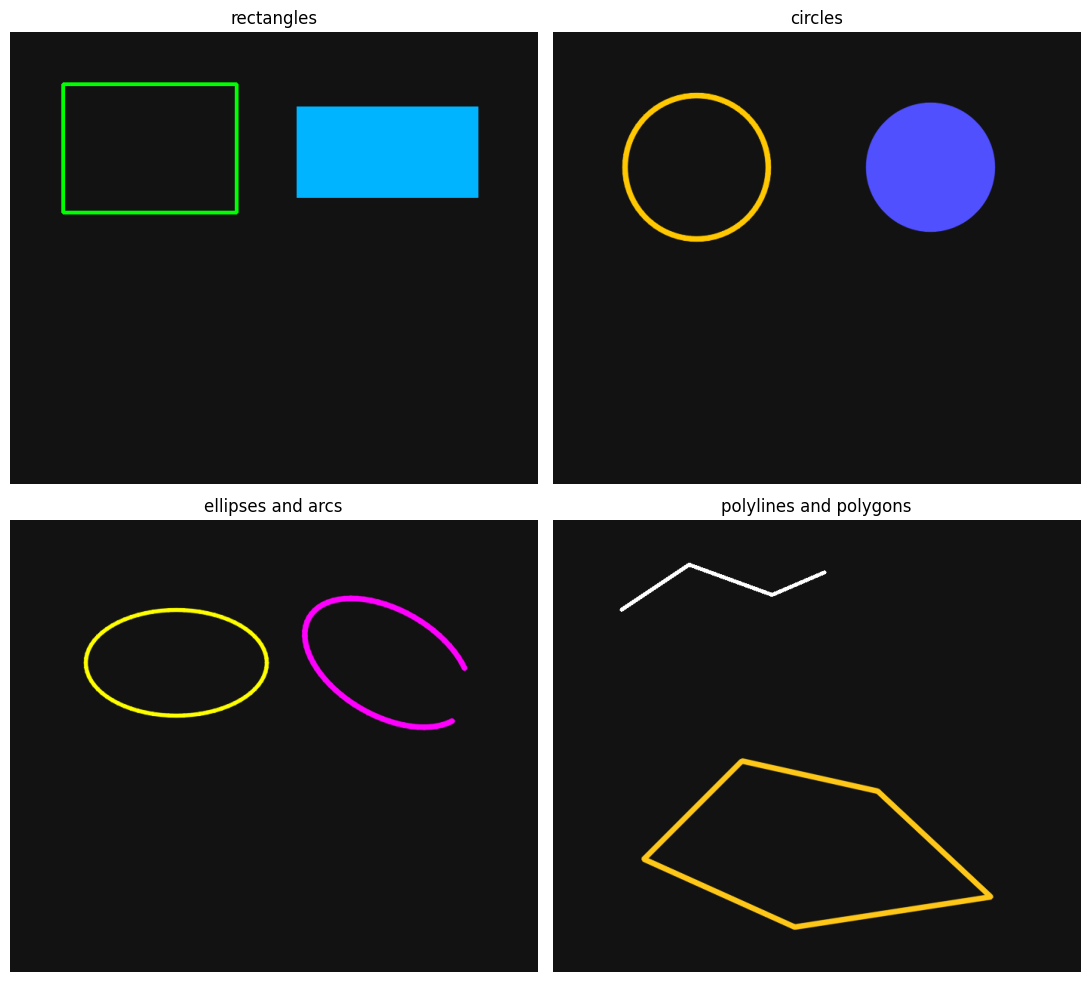

In [8]:
# 17.Rectangular circle drawing.pdf -----------------------------------------

shape_canvas = blank_canvas(700, 600, color=(18, 18, 18))



rect_demo = shape_canvas.copy()

cv2.rectangle(rect_demo, (70, 70), (300, 240), (0, 255, 0), 4, cv2.LINE_8)

cv2.rectangle(rect_demo, (380, 100), (620, 220), (255, 180, 0), cv2.FILLED)



circle_demo = shape_canvas.copy()

cv2.circle(circle_demo, (190, 180), 95, (0, 200, 255), 5, cv2.LINE_AA)

cv2.circle(circle_demo, (500, 180), 85, (255, 80, 80), -1, cv2.LINE_AA)



ellipse_demo = shape_canvas.copy()

cv2.ellipse(ellipse_demo, (220, 190), (120, 70), 0, 0, 360, (0, 255, 255), 4, cv2.LINE_AA)

cv2.ellipse(ellipse_demo, (500, 190), (120, 70), 30, 20, 320, (255, 0, 255), 6, cv2.LINE_AA)



polygon_demo = shape_canvas.copy()

pts = np.array([[120, 450], [250, 320], [430, 360], [580, 500], [320, 540]], dtype=np.int32)

cv2.polylines(polygon_demo, [pts], True, (25, 200, 255), 5, cv2.LINE_AA)

open_pts = np.array([[90, 120], [180, 60], [290, 100], [360, 70]], dtype=np.int32)

cv2.polylines(polygon_demo, [open_pts], False, (255, 255, 255), 3, cv2.LINE_4)



print("shape examples:")

print("  rectangle fill  -> thickness=cv2.FILLED")

print("  circle fill     -> thickness=-1")

print("  ellipse         -> (center, axes, angle, startAngle, endAngle)")

print("  polylines       -> pass a NumPy vertex array with isClosed=True/False")



panels = [

    (rect_demo, "rectangles"),

    (circle_demo, "circles"),

    (ellipse_demo, "ellipses and arcs"),

    (polygon_demo, "polylines and polygons"),

]



fig, axes = plt.subplots(2, 2, figsize=(11, 10))

for ax, (im, title) in zip(axes.flat, panels):

    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))

    ax.set_title(title)

    ax.axis("off")

plt.tight_layout()

plt.show()


## <a id='toc1_4_'></a>[`18.Text and picture drawing.pdf`](#toc0_)



What it covers:

- Overlaying text on an existing image with `cv2.putText`.

- Choosing font face, font scale, color, thickness, and anti-aliased rendering.

- Combining text with previously drawn shapes to annotate a picture.


### Overlaying text on an image



`cv2.putText` writes characters directly into an image array. The anchor point you pass in is the text origin, so changing that coordinate moves the label around the picture.



### Choosing font face, size, color, and thickness



OpenCV exposes several Hershey fonts and lets you control scale, BGR color, stroke thickness, and the line type used to render the glyph edges. `cv2.LINE_AA` usually gives the cleanest result.



### Combining text with shapes to annotate a picture



Text becomes much more useful when it is paired with rectangles, lines, and highlight boxes. This is the standard pattern for labeling regions of interest and building quick visual debugging overlays.



Core APIs:

- `cv2.putText(img, text, origin, fontFace, fontScale, color, thickness, lineType)`

- Common fonts: `cv2.FONT_HERSHEY_SIMPLEX`, `cv2.FONT_HERSHEY_DUPLEX`, `cv2.FONT_HERSHEY_SCRIPT_SIMPLEX`


font examples:
  SIMPLEX, DUPLEX, and SCRIPT_SIMPLEX shown on a resized display copy
display image: 900x1600
annotation box: top-left=(180, 400), bottom-right=(720, 1200)


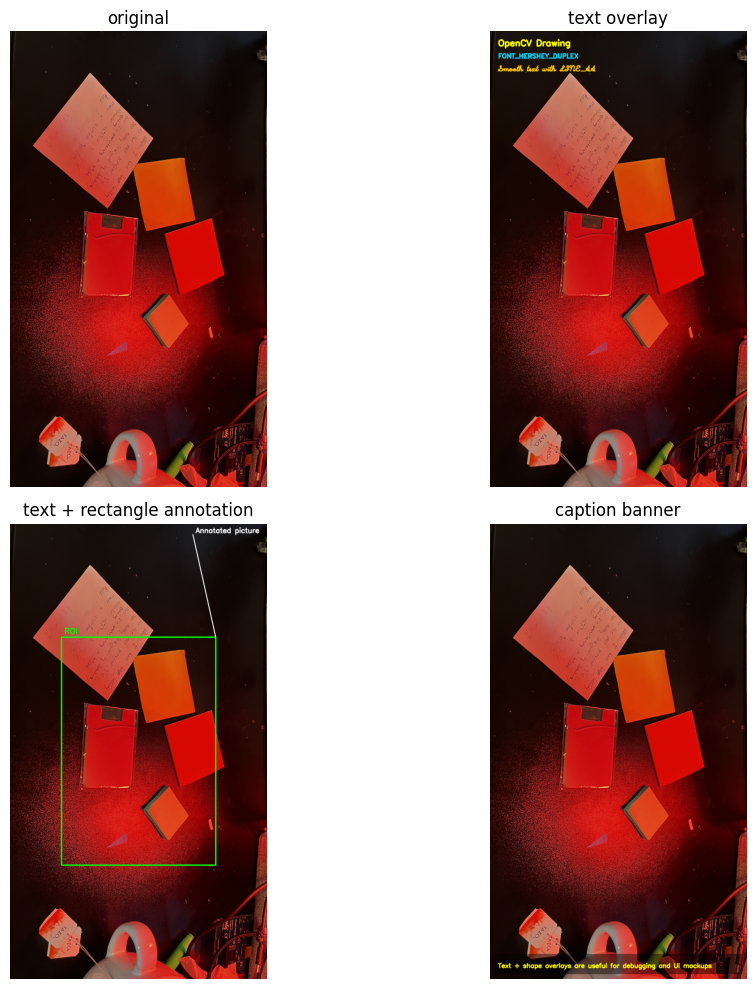

In [9]:
# 18.Text and picture drawing.pdf -------------------------------------------

display_w = 900

display_h = int(h * display_w / w)

photo = cv2.resize(img, (display_w, display_h), interpolation=cv2.INTER_AREA)

ph, pw = photo.shape[:2]



font = cv2.FONT_HERSHEY_SIMPLEX

title_scale = 1.0

body_scale = 0.75

script_scale = 0.9

thick = 2

margin = 28



text_demo = photo.copy()

cv2.putText(text_demo, "OpenCV Drawing", (margin, 52), cv2.FONT_HERSHEY_SIMPLEX, title_scale, (0, 255, 255), 3, cv2.LINE_AA)

cv2.putText(text_demo, "FONT_HERSHEY_DUPLEX", (margin, 95), cv2.FONT_HERSHEY_DUPLEX, body_scale, (255, 220, 0), 2, cv2.LINE_AA)

cv2.putText(text_demo, "Smooth text with LINE_AA", (margin, 140), cv2.FONT_HERSHEY_SCRIPT_SIMPLEX, script_scale, (0, 200, 255), 2, cv2.LINE_AA)



annotated = photo.copy()

box_tl = (pw // 5, ph // 4)

box_br = (pw * 4 // 5, ph * 3 // 4)

label_xy = (pw - 250, 34)

cv2.rectangle(annotated, box_tl, box_br, (0, 255, 0), 3)

cv2.putText(annotated, "ROI", (box_tl[0] + 10, box_tl[1] - 12), font, 0.9, (0, 255, 0), 2, cv2.LINE_AA)

cv2.line(annotated, (box_br[0], box_tl[1]), (label_xy[0] - 10, label_xy[1] + 6), (255, 255, 255), 2, cv2.LINE_AA)

cv2.putText(annotated, "Annotated picture", label_xy, font, 0.8, (255, 255, 255), 2, cv2.LINE_AA)



overlay = photo.copy()

cv2.rectangle(overlay, (18, ph - 88), (pw - 18, ph - 18), (0, 0, 0), cv2.FILLED)

banner = cv2.addWeighted(overlay, 0.45, photo, 0.55, 0)

cv2.putText(banner, "Text + shape overlays are useful for debugging and UI mockups", (28, ph - 40), font, 0.72, (0, 255, 255), 2, cv2.LINE_AA)



print("font examples:")

print("  SIMPLEX, DUPLEX, and SCRIPT_SIMPLEX shown on a resized display copy")

print(f"display image: {pw}x{ph}")

print(f"annotation box: top-left={box_tl}, bottom-right={box_br}")



panels = [

    (cv2.cvtColor(photo, cv2.COLOR_BGR2RGB), "original"),

    (cv2.cvtColor(text_demo, cv2.COLOR_BGR2RGB), "text overlay"),

    (cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB), "text + rectangle annotation"),

    (cv2.cvtColor(banner, cv2.COLOR_BGR2RGB), "caption banner"),

]



fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (im, title) in zip(axes.flat, panels):

    ax.imshow(im)

    ax.set_title(title)

    ax.axis("off")

plt.tight_layout()

plt.show()
